<a href="https://colab.research.google.com/github/scientificbroker/business-analytics-para-startups/blob/main/Code%20Colabs/M6_VC_Valuacion_Startup_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M6 — Método VC: Valuación de Startups LATAM

**Caso de uso:** SaaS B2B de logística (LogTech) buscando Serie A en LATAM  
*(Inspirado en Nowports, Flexe LATAM, Loggro, Nuvocargo)*

---

## Objetivos del módulo

1. Aplicar el **Método VC** (múltiplos de salida + IRR objetivo del fondo)
2. Calcular valuación por **Comparables de Transacciones LATAM** (EV/ARR)
3. Simular distribución de valuaciones con **Monte Carlo** (10,000 escenarios)
4. Calcular la estructura de equity y dilución post-inversión
5. Generar un resumen ejecutivo listo para el pitch deck

---

> **Disclaimer obligatorio:** Los resultados son ilustrativos basados en datos simulados y benchmarks públicos de la región. Para valuaciones en una negociación real, validar múltiplos con transacciones comparables RECIENTES y consultar con un asesor financiero especializado en venture capital.

> **Repositorio:** [business-analytics-para-startups](https://github.com/scientificbroker/business-analytics-para-startups)

## 0. Instalación de dependencias

In [1]:
# Instala las dependencias necesarias (ejecuta solo una vez en Google Colab)
%pip install pandas numpy matplotlib seaborn scipy -q


## 1. Parámetros de tu startup

**Esta es la sección más importante del notebook.**  
Reemplaza los valores del diccionario `STARTUP` con los datos reales de tu empresa.  
El análisis completo se recalculará automáticamente.

**¿Qué datos necesitas?**
- ARR actual y proyectado (de tu modelo financiero)
- Métricas de unit economics: churn, NRR, margen bruto, LTV, CAC
- Monto de inversión que estás buscando y runway actual

In [2]:
# ════════════════════════════════════════════════════════
# PARÁMETROS DE TU STARTUP — EDITAR CON DATOS REALES
# ════════════════════════════════════════════════════════

STARTUP = {
    # ── IDENTIFICACIÓN ─────────────────────────────────
    'nombre':           'LogFlow LATAM',
    'sector':           'LogTech B2B',
    'pais_principal':   'México',
    'etapa':            'Serie A',
    'modelo_negocio':   'SaaS B2B',
    'moneda':           'USD',

    # ── MÉTRICAS FINANCIERAS ACTUALES ─────────────────
    'arr_actual':       1_200_000,   # ARR actual en USD
    'mrr_ultimo':         105_000,   # MRR del último mes
    'crecimiento_mom':       0.08,   # crecimiento MoM (8% = ~157% anual)
    'crecimiento_yoy':       0.95,   # crecimiento YoY (95%)

    # ── UNIT ECONOMICS ─────────────────────────────────
    'gross_margin':          0.72,   # margen bruto (benchmark SaaS LATAM: 65-80%)
    'churn_anual':           0.12,   # churn anual (benchmark SaaS B2B LATAM: 8-15%)
    'nrr':                   1.18,   # Net Revenue Retention (>100% = expansión)
    'cac':                  2_800,   # CAC por cliente en USD
    'ltv':                 22_000,   # LTV por cliente en USD

    # ── MÉTRICAS OPERATIVAS ───────────────────────────
    'n_clientes':             115,   # clientes activos
    'arpu_anual':          10_400,   # ARPU anual por cliente
    'n_empleados':             28,   # tamaño del equipo

    # ── FINANCIAMIENTO ────────────────────────────────
    'inversion_buscada':  3_000_000, # monto de la ronda en USD
    'cash_burn_mensual':    95_000,  # burn rate mensual
    'runway_meses':             18,  # runway actual

    # ── PROYECCIONES ─────────────────────────────────
    'arr_proyectado_y3':  8_500_000, # ARR en 3 años (escenario base)
    'arr_proyectado_y5': 22_000_000, # ARR en 5 años (escenario optimista)

    # ── PARÁMETROS DE VALUACIÓN ──────────────────────
    'multiple_salida_base':    7.0,  # EV/ARR múltiplo en exit (benchmark LogTech LATAM)
    'multiple_salida_opt':    10.0,  # escenario optimista
    'multiple_salida_pes':     4.0,  # escenario pesimista
    'irr_objetivo_fondo':      0.25, # IRR que busca el fondo (25% típico VC LATAM)
    'anos_hasta_exit':          5,   # horizonte de inversión en años
    'dilution_futuras':        0.35, # dilución adicional esperada en rondas futuras
}

## 2. Importaciones

In [3]:
%matplotlib inline
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
COLORES = {'optimista': '#2ECC71', 'base': '#3498DB', 'pesimista': '#E74C3C',
           'mc': '#9B59B6', 'texto': '#2C3E50'}
plt.rcParams.update({'figure.figsize': (14, 8), 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
np.random.seed(42)

# Mostrar resumen de inputs
print('Startup:         ', STARTUP['nombre'], '(', STARTUP['sector'], ')')
print('Pais principal:  ', STARTUP['pais_principal'])
print('Etapa:           ', STARTUP['etapa'])
print()
print(f"ARR Actual:       ${STARTUP['arr_actual']:>12,.0f} USD")
print(f"Crecimiento YoY:  {STARTUP['crecimiento_yoy']:.0%}")
print(f"Gross Margin:     {STARTUP['gross_margin']:.0%}")
print(f"Churn Anual:      {STARTUP['churn_anual']:.0%}")
print(f"NRR:              {STARTUP['nrr']:.0%}")
print(f"LTV/CAC Ratio:    {STARTUP['ltv']/STARTUP['cac']:.1f}x")
print(f"Burn Rate:        ${STARTUP['cash_burn_mensual']:>10,.0f} USD/mes")
print(f"Runway:           {STARTUP['runway_meses']} meses")


Startup:          LogFlow LATAM ( LogTech B2B )
Pais principal:   México
Etapa:            Serie A

ARR Actual:       $   1,200,000 USD
Crecimiento YoY:  95%
Gross Margin:     72%
Churn Anual:      12%
NRR:              118%
LTV/CAC Ratio:    7.9x
Burn Rate:        $    95,000 USD/mes
Runway:           18 meses


## 3. Método VC: Valuación por exit múltiple + IRR

**Lógica del Método VC:**
1. Estima el valor de la empresa en el exit: `EV_exit = ARR_exit × múltiplo`
2. Descuenta ese valor al presente usando el IRR objetivo del fondo: `PV = EV_exit / (1+IRR)^años`
3. Ajusta por la dilución que tendrá el fondo en rondas futuras
4. El resultado es el Pre-money que justifica la inversión para el fondo

**¿Por qué el IRR?** Los fondos de VC típicamente buscan un retorno de 25-30% anual (IRR) sobre su inversión. Si la startup no les da ese retorno esperado, preferirán invertir en otra.

In [4]:
def metodo_vc(arr_exit, multiple_exit, anos, irr_objetivo, dilution_futuras):
    """Calcula la valuación pre-money usando el método VC clásico."""
    ev_exit      = arr_exit * multiple_exit
    pv_exit      = ev_exit / (1 + irr_objetivo) ** anos
    pre_money_vc = pv_exit / (1 + dilution_futuras)
    return ev_exit, pv_exit, pre_money_vc

escenarios = {
    'Pesimista': {
        'arr_exit': STARTUP['arr_proyectado_y3'],
        'multiple': STARTUP['multiple_salida_pes'],
        'anos':     STARTUP['anos_hasta_exit'],
    },
    'Base': {
        'arr_exit': STARTUP['arr_proyectado_y5'],
        'multiple': STARTUP['multiple_salida_base'],
        'anos':     STARTUP['anos_hasta_exit'],
    },
    'Optimista': {
        'arr_exit': STARTUP['arr_proyectado_y5'] * 1.4,
        'multiple': STARTUP['multiple_salida_opt'],
        'anos':     STARTUP['anos_hasta_exit'] - 1,
    },
}

print(f'IRR objetivo del fondo: {STARTUP["irr_objetivo_fondo"]:.0%}')
print(f'Dilución esperada post-ronda: {STARTUP["dilution_futuras"]:.0%}')
print()

resultados_vc = {}
rows = []
for escenario, params in escenarios.items():
    ev_exit, pv_exit, pre_money = metodo_vc(
        params['arr_exit'], params['multiple'],
        params['anos'], STARTUP['irr_objetivo_fondo'],
        STARTUP['dilution_futuras']
    )
    resultados_vc[escenario] = {'arr_exit': params['arr_exit'], 'multiple': params['multiple'],
                                 'ev_exit': ev_exit, 'pre_money': pre_money}
    rows.append({
        'Escenario': escenario,
        'ARR Exit (M USD)': round(params['arr_exit']/1e6, 1),
        'Múltiplo': params['multiple'],
        'EV Exit (M USD)': round(ev_exit/1e6, 1),
        'Pre-money (M USD)': round(pre_money/1e6, 2),
    })

display(pd.DataFrame(rows).set_index('Escenario'))

pre_money_base = resultados_vc['Base']['pre_money']
post_money     = pre_money_base + STARTUP['inversion_buscada']
equity_fondo   = STARTUP['inversion_buscada'] / post_money

print(f'\nPre-money (Escenario Base): ${pre_money_base/1e6:.2f}M USD')
print(f'Post-money:                 ${post_money/1e6:.2f}M USD')
print(f'Equity entregado al fondo:  {equity_fondo:.1%}')
print(f'MOIC implícito del fondo:   {resultados_vc["Base"]["ev_exit"] * (1-STARTUP["dilution_futuras"]) / post_money:.1f}x')

IRR objetivo del fondo: 25%
Dilución esperada post-ronda: 35%



,ARR Exit (M USD),Múltiplo,EV Exit (M USD),Pre-money (M USD)
Escenario,,,,
Pesimista,8.5,4.0,34.0,8.25
Base,22.0,7.0,154.0,37.38
Optimista,30.8,10.0,308.0,93.45



Pre-money (Escenario Base): $37.38M USD
Post-money:                 $40.38M USD
Equity entregado al fondo:  7.4%
MOIC implícito del fondo:   2.5x


## 4. Comparable Transactions — Múltiplos EV/ARR LATAM

Los **Comparables de Transacciones** anclan la valuación en deals reales del mercado.  
Usamos múltiplos EV/ARR de transacciones de LogTech y SaaS B2B en LATAM (2023-2025).

**Ajuste por crecimiento:** una startup que crece al 95% YoY merece un múltiplo más alto que el promedio del mercado que crece al 50%. El factor de ajuste compensa esta diferencia.

In [5]:
comparables = pd.DataFrame({
    'empresa':          ['Nowports', 'Nuvocargo', 'Loggro', 'Teclogi', 'Drip Capital',
                         'Kubo Fin.', 'Conekta', 'Alegra', 'Pagatodo', 'LATAM LogTech Prom.'],
    'pais':             ['México', 'México', 'Colombia', 'Colombia', 'México',
                         'México', 'México', 'Colombia', 'México', 'LATAM'],
    'etapa':            ['Serie B', 'Serie B', 'Serie A', 'Serie A', 'Serie B',
                         'Serie B', 'Serie C', 'Serie A', 'Seed', 'PROM.'],
    'arr_musd':         [18.0, 12.0, 4.5, 3.2, 25.0, 15.0, 30.0, 5.0, 1.8, None],
    'valuacion_musd':   [150, 90, 28, 18, 220, 100, 200, 30, 8, None],
    'ev_arr_multiple':  [8.3, 7.5, 6.2, 5.6, 8.8, 6.7, 6.7, 6.0, 4.4, 7.0],
    'año':             [2024, 2024, 2023, 2023, 2024, 2023, 2024, 2023, 2023, None],
})

multiple_mediana = comparables['ev_arr_multiple'].median()
multiple_p25     = comparables['ev_arr_multiple'].quantile(0.25)
multiple_p75     = comparables['ev_arr_multiple'].quantile(0.75)

print('Transacciones Comparables LogTech/SaaS B2B LATAM 2023-2025:')
display(comparables[['empresa', 'pais', 'etapa', 'arr_musd', 'valuacion_musd', 'ev_arr_multiple', 'año']])

val_comparable_p25 = STARTUP['arr_actual'] * multiple_p25 / 1e6
val_comparable_med = STARTUP['arr_actual'] * multiple_mediana / 1e6
val_comparable_p75 = STARTUP['arr_actual'] * multiple_p75 / 1e6

print(f'\nMúltiplo P25: {multiple_p25:.1f}x → Valuación: ${val_comparable_p25:.1f}M')
print(f'Múltiplo P50: {multiple_mediana:.1f}x → Valuación: ${val_comparable_med:.1f}M')
print(f'Múltiplo P75: {multiple_p75:.1f}x → Valuación: ${val_comparable_p75:.1f}M')

# Ajuste por crecimiento superior al promedio
ajuste_growth = 1 + (STARTUP['crecimiento_yoy'] - 0.50) * 0.5
val_ajustada  = val_comparable_med * ajuste_growth
print(f'\nAjuste por crecimiento YoY ({STARTUP["crecimiento_yoy"]:.0%}):')
print(f'Factor: {ajuste_growth:.2f}x → Valuación ajustada: ${val_ajustada:.1f}M')

Transacciones Comparables LogTech/SaaS B2B LATAM 2023-2025:


,empresa,pais,etapa,arr_musd,valuacion_musd,ev_arr_multiple,año
0,Nowports,México,Serie B,18.0,150.0,8.3,2024.0
1,Nuvocargo,México,Serie B,12.0,90.0,7.5,2024.0
2,Loggro,Colombia,Serie A,4.5,28.0,6.2,2023.0
3,Teclogi,Colombia,Serie A,3.2,18.0,5.6,2023.0
4,Drip Capital,México,Serie B,25.0,220.0,8.8,2024.0
5,Kubo Fin.,México,Serie B,15.0,100.0,6.7,2023.0
6,Conekta,México,Serie C,30.0,200.0,6.7,2024.0
7,Alegra,Colombia,Serie A,5.0,30.0,6.0,2023.0
8,Pagatodo,México,Seed,1.8,8.0,4.4,2023.0
9,LATAM LogTech Prom.,LATAM,PROM.,NaN,NaN,7.0,NaN



Múltiplo P25: 6.0x → Valuación: $7.3M
Múltiplo P50: 6.7x → Valuación: $8.0M
Múltiplo P75: 7.4x → Valuación: $8.8M

Ajuste por crecimiento YoY (95%):
Factor: 1.23x → Valuación ajustada: $9.8M


## 5. Simulación Monte Carlo (10,000 escenarios)

Las valuaciones no son un número único — son una **distribución de posibilidades**.  
Monte Carlo simula 10,000 combinaciones de parámetros inciertos y muestra la distribución completa.

**Por qué importa para una negociación:**
- El **P50** (mediana) es el punto de partida razonable
- El **P25** es el piso de negociación (no aceptes menos sin datos sólidos)
- El **P75** es el techo aspiracional para el pitch
- La anchura de la distribución muestra el nivel de incertidumbre (más ancha = más riesgo)

In [6]:
N_SIM = 10_000

arr_exit_sim = np.random.lognormal(
    mean=np.log(STARTUP['arr_proyectado_y5']), sigma=0.35, size=N_SIM
)
multiple_sim = np.random.triangular(
    left=STARTUP['multiple_salida_pes'],
    mode=STARTUP['multiple_salida_base'],
    right=STARTUP['multiple_salida_opt'],
    size=N_SIM
)
irr_sim       = np.random.normal(loc=STARTUP['irr_objetivo_fondo'], scale=0.04, size=N_SIM).clip(0.15, 0.40)
dilution_sim  = np.random.uniform(0.25, 0.45, N_SIM)

ev_exit_sim   = arr_exit_sim * multiple_sim
premoney_sim  = ev_exit_sim / ((1 + irr_sim) ** STARTUP['anos_hasta_exit']) / (1 + dilution_sim)

p10    = np.percentile(premoney_sim, 10) / 1e6
p25    = np.percentile(premoney_sim, 25) / 1e6
p50    = np.percentile(premoney_sim, 50) / 1e6
p75    = np.percentile(premoney_sim, 75) / 1e6
p90    = np.percentile(premoney_sim, 90) / 1e6
media_mc = np.mean(premoney_sim) / 1e6

print(f'Distribución de Pre-money Valuations ({N_SIM:,} escenarios):')
print(f'  P10 (escenario difícil):   ${p10:.1f}M')
print(f'  P25:                       ${p25:.1f}M')
print(f'  P50 (mediana):             ${p50:.1f}M')
print(f'  Media ponderada:           ${media_mc:.1f}M')
print(f'  P75:                       ${p75:.1f}M')
print(f'  P90 (escenario favorable): ${p90:.1f}M')

Distribución de Pre-money Valuations (10,000 escenarios):
  P10 (escenario difícil):   $21.4M
  P25:                       $27.8M
  P50 (mediana):             $37.3M
  Media ponderada:           $40.6M
  P75:                       $49.4M
  P90 (escenario favorable): $63.7M


## 6. Estructura de equity post-inversión

In [7]:
equity_structure = {
    'Fundadores':      0.55,
    'Inversores Seed': 0.10,
    'Pool de Opciones': 0.10,
    f'Serie A ({STARTUP["nombre"][:8]}...)': equity_fondo,
}

# Normalizar para que sume exactamente 1
total = sum(equity_structure.values())
equity_structure = {k: v / total for k, v in equity_structure.items()}

print(f'Pre-money negociación (escenario base): ${pre_money_base/1e6:.1f}M')
print(f'Inversión buscada:                      ${STARTUP["inversion_buscada"]/1e6:.1f}M')
print(f'Post-money:                             ${post_money/1e6:.1f}M')
print()
print('Distribución de Equity Post-Serie A:')
for stakeholder, pct in equity_structure.items():
    valor = pct * post_money
    print(f'  {stakeholder:<30} {pct:.1%}  (${valor/1e6:.2f}M)')

Pre-money negociación (escenario base): $37.4M
Inversión buscada:                      $3.0M
Post-money:                             $40.4M

Distribución de Equity Post-Serie A:
  Fundadores                     66.7%  ($26.94M)
  Inversores Seed                12.1%  ($4.90M)
  Pool de Opciones               12.1%  ($4.90M)
  Serie A (LogFlow ...)          9.0%  ($3.64M)


## 7. Dashboard ejecutivo de valuación

Estas visualizaciones están diseñadas para incluir en el **pitch deck** de Serie A.  
El gráfico de Monte Carlo es especialmente poderoso en conversaciones con fondos porque muestra que el emprendedor entiende la incertidumbre del negocio — una señal de madurez analítica.

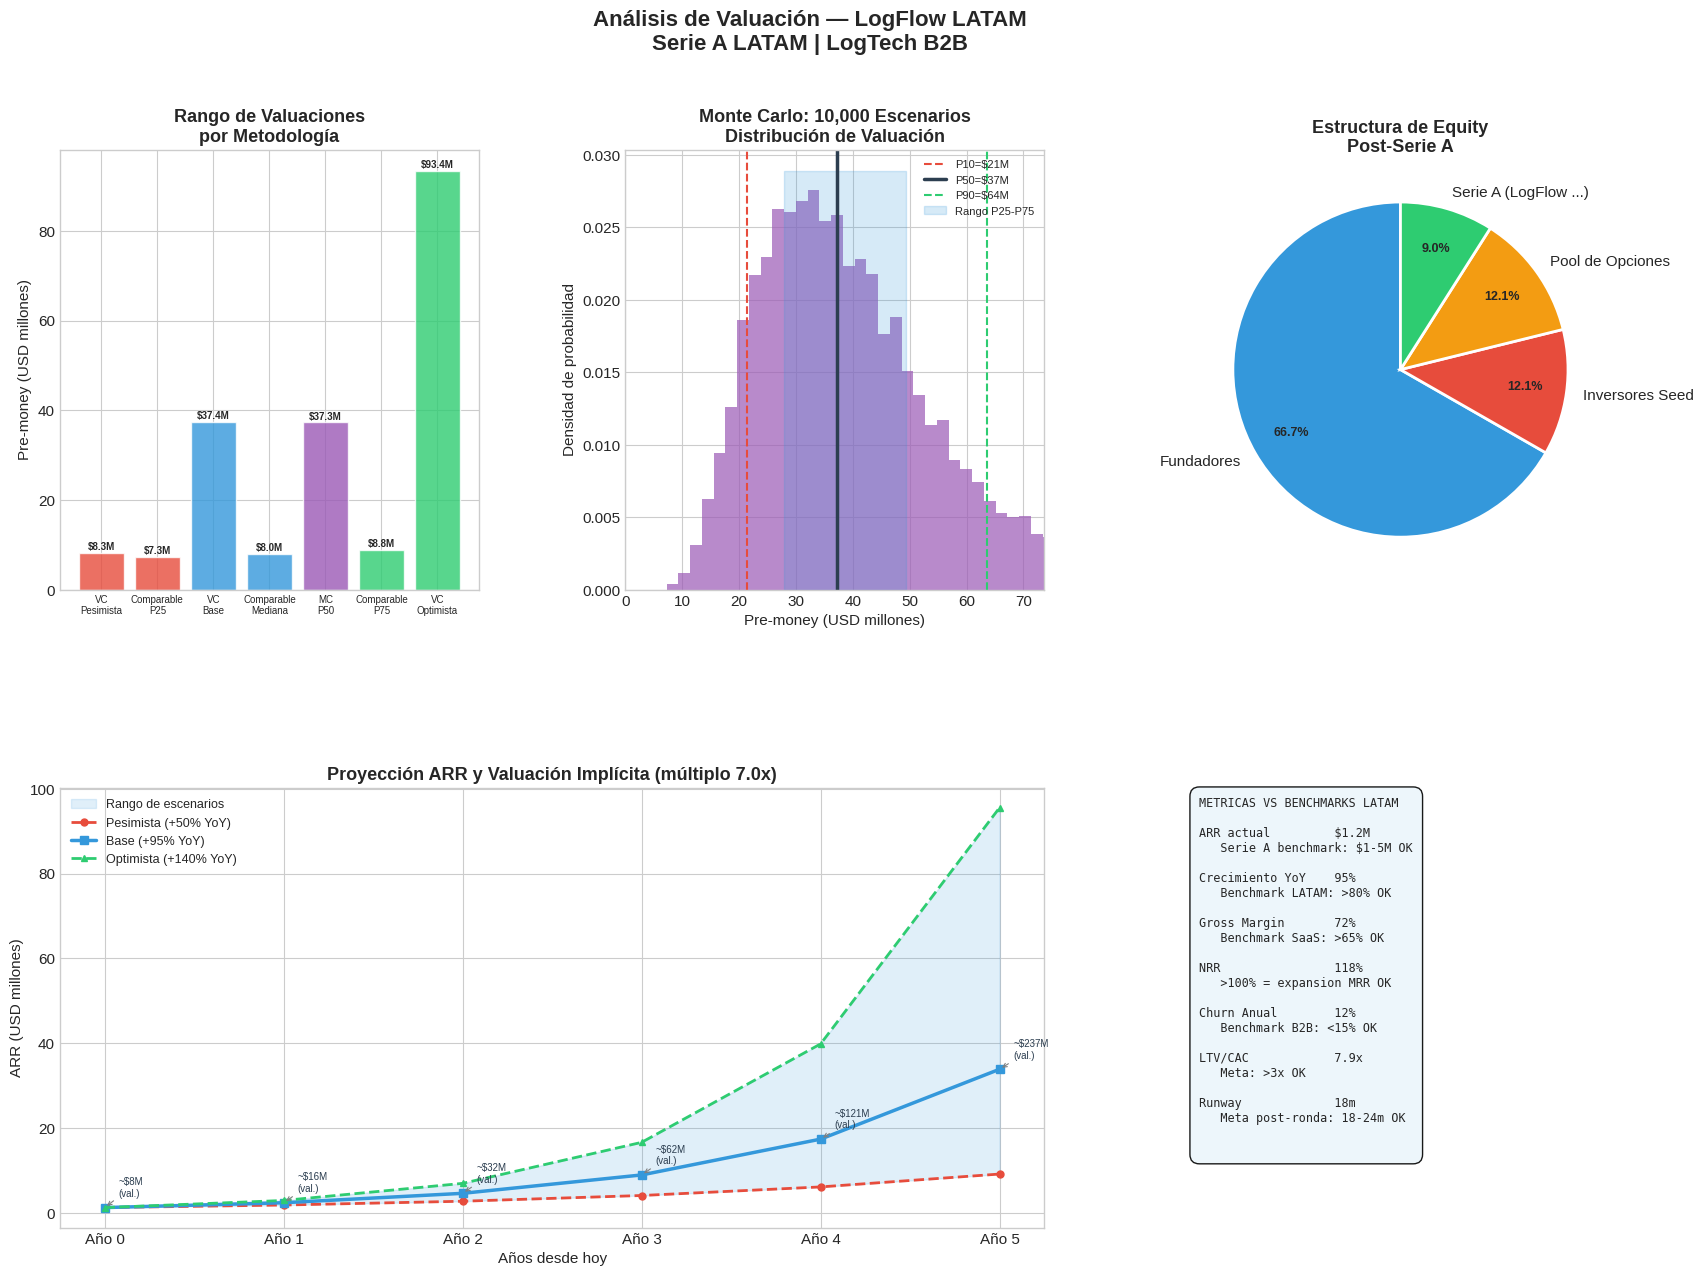

In [8]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle(f'Análisis de Valuación — {STARTUP["nombre"]}\nSerie A LATAM | {STARTUP["sector"]}',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Comparación de metodologías
ax1 = fig.add_subplot(gs[0, 0])
metodos = ['VC\nPesimista', 'Comparable\nP25', 'VC\nBase',
           'Comparable\nMediana', 'MC\nP50', 'Comparable\nP75', 'VC\nOptimista']
valores = [
    resultados_vc['Pesimista']['pre_money'] / 1e6, val_comparable_p25,
    resultados_vc['Base']['pre_money'] / 1e6,      val_comparable_med,
    p50, val_comparable_p75,
    resultados_vc['Optimista']['pre_money'] / 1e6,
]
bar_colors = ['#E74C3C', '#E74C3C', '#3498DB', '#3498DB', '#9B59B6', '#2ECC71', '#2ECC71']
bars = ax1.bar(metodos, valores, color=bar_colors, alpha=0.8, edgecolor='white')
ax1.set_ylabel('Pre-money (USD millones)')
ax1.set_title('Rango de Valuaciones\npor Metodología')
ax1.tick_params(axis='x', labelsize=7)
for bar, val in zip(bars, valores):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f'${val:.1f}M', ha='center', va='bottom', fontsize=7, fontweight='bold')

# Plot 2: Monte Carlo
ax2 = fig.add_subplot(gs[0, 1])
vals_m = premoney_sim / 1e6
ax2.hist(vals_m, bins=80, color='#9B59B6', alpha=0.7, edgecolor='none', density=True)
ax2.axvline(p10, color='#E74C3C', linestyle='--', lw=1.5, label=f'P10=${p10:.0f}M')
ax2.axvline(p50, color='#2C3E50', linestyle='-',  lw=2.5, label=f'P50=${p50:.0f}M')
ax2.axvline(p90, color='#2ECC71', linestyle='--', lw=1.5, label=f'P90=${p90:.0f}M')
ymax = ax2.get_ylim()[1]
ax2.fill_betweenx([0, ymax if ymax > 0 else 0.01], p25, p75,
                  alpha=0.2, color='#3498DB', label=f'Rango P25-P75')
ax2.set_xlabel('Pre-money (USD millones)')
ax2.set_ylabel('Densidad de probabilidad')
ax2.set_title(f'Monte Carlo: {N_SIM:,} Escenarios\nDistribución de Valuación')
ax2.legend(fontsize=8)
ax2.set_xlim(0, np.percentile(vals_m, 95))

# Plot 3: Pie de equity
ax3 = fig.add_subplot(gs[0, 2])
colores_eq = ['#3498DB', '#E74C3C', '#F39C12', '#2ECC71']
wedges, texts, autotexts = ax3.pie(
    equity_structure.values(), labels=equity_structure.keys(),
    colors=colores_eq, autopct='%1.1f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
ax3.set_title('Estructura de Equity\nPost-Serie A')

# Plot 4: Proyección ARR con valuación implícita
ax4 = fig.add_subplot(gs[1, :2])
anos    = np.arange(0, STARTUP['anos_hasta_exit'] + 1)
arr_pes  = [STARTUP['arr_actual'] * (1 + 0.50)**a / 1e6 for a in anos]
arr_base = [STARTUP['arr_actual'] * (1 + 0.95)**a / 1e6 for a in anos]
arr_opt  = [STARTUP['arr_actual'] * (1 + 1.40)**a / 1e6 for a in anos]

ax4.fill_between(anos, arr_pes, arr_opt, alpha=0.15, color='#3498DB', label='Rango de escenarios')
ax4.plot(anos, arr_pes,  color='#E74C3C', lw=2, linestyle='--', marker='o', markersize=5, label='Pesimista (+50% YoY)')
ax4.plot(anos, arr_base, color='#3498DB', lw=2.5, linestyle='-', marker='s', markersize=6, label='Base (+95% YoY)')
ax4.plot(anos, arr_opt,  color='#2ECC71', lw=2, linestyle='--', marker='^', markersize=5, label='Optimista (+140% YoY)')

for a, arr_v in zip(anos, arr_base):
    val_implica = arr_v * STARTUP['multiple_salida_base']
    ax4.annotate(f'~${val_implica:.0f}M\n(val.)', (a, arr_v),
                 textcoords='offset points', xytext=(10, 8), fontsize=7,
                 color=COLORES['texto'], arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax4.set_xlabel('Años desde hoy')
ax4.set_ylabel('ARR (USD millones)')
ax4.set_title(f'Proyección ARR y Valuación Implícita (múltiplo {STARTUP["multiple_salida_base"]}x)')
ax4.legend(fontsize=9)
ax4.set_xticks(anos)
ax4.set_xticklabels([f'Año {a}' for a in anos])

# Plot 5: KPIs vs benchmarks LATAM
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
kpis = [
    ('ARR actual',      f'${STARTUP["arr_actual"]/1e6:.1f}M',   'Serie A benchmark: $1-5M OK'),
    ('Crecimiento YoY', f'{STARTUP["crecimiento_yoy"]:.0%}',     'Benchmark LATAM: >80% OK'),
    ('Gross Margin',    f'{STARTUP["gross_margin"]:.0%}',         'Benchmark SaaS: >65% OK'),
    ('NRR',             f'{STARTUP["nrr"]:.0%}',                  '>100% = expansion MRR OK'),
    ('Churn Anual',     f'{STARTUP["churn_anual"]:.0%}',          'Benchmark B2B: <15% OK'),
    ('LTV/CAC',         f'{STARTUP["ltv"]/STARTUP["cac"]:.1f}x', 'Meta: >3x OK'),
    ('Runway',          f'{STARTUP["runway_meses"]}m',            'Meta post-ronda: 18-24m OK'),
]
texto_kpis = 'METRICAS VS BENCHMARKS LATAM\n\n'
for kpi, valor, bench in kpis:
    texto_kpis += f'{kpi:<18} {valor:<10}\n   {bench}\n\n'

ax5.text(0.02, 0.98, texto_kpis, transform=ax5.transAxes,
         fontsize=8.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#EBF5FB', alpha=0.9, pad=0.8))

plt.savefig('M6_valuacion_startup.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Resumen ejecutivo para el pitch deck

Este resumen consolida las tres metodologías en un rango de negociación y un punto de partida recomendado.  
**Nunca presentes una cifra única como "la valuación correcta"** — siempre presenta un rango con los supuestos detrás.

In [9]:
rango_bajo  = min(p25, resultados_vc['Pesimista']['pre_money'] / 1e6)
rango_alto  = max(p75, resultados_vc['Optimista']['pre_money'] / 1e6)
punto_medio = (rango_bajo + rango_alto) / 2

print('=' * 60)
print('RESUMEN EJECUTIVO DE VALUACION — SERIE A')
print(f'{STARTUP["nombre"]}')
print('=' * 60)
print()
print('METODOLOGIA              RANGO PRE-MONEY (USD)')
print('-' * 60)
print(f'Método VC           ${resultados_vc["Pesimista"]["pre_money"]/1e6:.1f}M – ${resultados_vc["Optimista"]["pre_money"]/1e6:.1f}M')
print(f'Comparables LATAM   ${val_comparable_p25:.1f}M – ${val_comparable_p75:.1f}M')
print(f'Monte Carlo P25-P75 ${p25:.1f}M – ${p75:.1f}M')
print('=' * 60)
print(f'RANGO DE NEGOCIACION:     ${rango_bajo:.1f}M – ${rango_alto:.1f}M')
print(f'PUNTO DE PARTIDA:         ${punto_medio:.1f}M')
print('=' * 60)
print(f'Inversión buscada:   ${STARTUP["inversion_buscada"]/1e6:.1f}M')
print(f'Equity a entregar:   {equity_fondo:.1%}')
print(f'Post-money:          ${post_money/1e6:.1f}M')
print('=' * 60)

RESUMEN EJECUTIVO DE VALUACION — SERIE A
LogFlow LATAM

METODOLOGIA              RANGO PRE-MONEY (USD)
------------------------------------------------------------
Método VC           $8.3M – $93.4M
Comparables LATAM   $7.3M – $8.8M
Monte Carlo P25-P75 $27.8M – $49.4M
RANGO DE NEGOCIACION:     $8.3M – $93.4M
PUNTO DE PARTIDA:         $50.9M
Inversión buscada:   $3.0M
Equity a entregar:   7.4%
Post-money:          $40.4M


## 9. Disclaimer y buenas prácticas de negociación

> **Lectura obligatoria antes de usar estos números en una negociación real.**

In [10]:
print('DISCLAIMER — LECTURA OBLIGATORIA')
print('=' * 60)
print("""
  1. Validar múltiplos con transacciones comparables RECIENTES
     en LATAM. Los datos de 2022-2023 pueden no reflejar el
     entorno actual de VC (tasas de interés, apetito de riesgo).

  2. Consultar con un asesor financiero especializado en
     venture capital antes de presentar estas cifras en una
     negociación real.

  3. Nunca presentar una cifra única como 'la valuación correcta'.
     Siempre presentar un rango con los supuestos detrás.

  4. El contexto macroeconómico de LATAM (tipo de cambio,
     inflación, tasas) afecta significativamente los múltiplos.
""")

DISCLAIMER — LECTURA OBLIGATORIA

  1. Validar múltiplos con transacciones comparables RECIENTES
     en LATAM. Los datos de 2022-2023 pueden no reflejar el
     entorno actual de VC (tasas de interés, apetito de riesgo).

  2. Consultar con un asesor financiero especializado en
     venture capital antes de presentar estas cifras en una
     negociación real.

  3. Nunca presentar una cifra única como 'la valuación correcta'.
     Siempre presentar un rango con los supuestos detrás.

  4. El contexto macroeconómico de LATAM (tipo de cambio,
     inflación, tasas) afecta significativamente los múltiplos.



## 10. Conclusiones ejecutivas y próximos pasos

In [11]:
print('=' * 65)
print('CONCLUSIONES EJECUTIVAS — VALUACION VC LOGTECH LATAM')
print('=' * 65)
print(f"""
HALLAZGOS CLAVE:

  1. La valuación justificada por datos está en el rango
     ${rango_bajo:.0f}M – ${rango_alto:.0f}M.
     El punto de partida para negociar es ${punto_medio:.0f}M pre-money.

  2. El NRR de {STARTUP['nrr']:.0%} es el KPI más poderoso del pitch:
     indica que los clientes actuales pagan más cada año
     → crecimiento implícito sin nuevo marketing.

  3. El LTV/CAC de {STARTUP['ltv']/STARTUP['cac']:.1f}x es sólido. Por cada $1 invertido
     en adquisición se recuperan ${STARTUP['ltv']/STARTUP['cac']:.0f} en valor de cliente.

  4. Con {STARTUP['runway_meses']} meses de runway post-ronda
     (${STARTUP['inversion_buscada']/1e6:.1f}M / ${STARTUP['cash_burn_mensual']/1e3:.0f}K burn),
     hay tiempo para alcanzar el ARR que justifique la Serie B.

ACCIONES INMEDIATAS:
  → Preparar Data Room: métricas reales vs benchmarks de este análisis.
  → Identificar 10 fondos LATAM activos en LogTech/SaaS B2B:
    Kaszek, a16z LATAM, Softbank LATAM, Nazca, Canary, Ignia,
    Monashees, Magma, Vine Ventures, ALLVP.
  → Proyectar uso de fondos: equipo (40%), producto (30%), ventas (30%).

PROXIMO ANALISIS RECOMENDADO:
  → M5 (Prophet) para proyectar ARR con mayor precisión estadística.
  → M3 (LTV/CAC) para mostrar unit economics por canal de adquisición.
""")

CONCLUSIONES EJECUTIVAS — VALUACION VC LOGTECH LATAM

HALLAZGOS CLAVE:

  1. La valuación justificada por datos está en el rango
     $8M – $93M.
     El punto de partida para negociar es $51M pre-money.

  2. El NRR de 118% es el KPI más poderoso del pitch:
     indica que los clientes actuales pagan más cada año
     → crecimiento implícito sin nuevo marketing.

  3. El LTV/CAC de 7.9x es sólido. Por cada $1 invertido
     en adquisición se recuperan $8 en valor de cliente.

  4. Con 18 meses de runway post-ronda
     ($3.0M / $95K burn),
     hay tiempo para alcanzar el ARR que justifique la Serie B.

ACCIONES INMEDIATAS:
  → Preparar Data Room: métricas reales vs benchmarks de este análisis.
  → Identificar 10 fondos LATAM activos en LogTech/SaaS B2B:
    Kaszek, a16z LATAM, Softbank LATAM, Nazca, Canary, Ignia,
    Monashees, Magma, Vine Ventures, ALLVP.
  → Proyectar uso de fondos: equipo (40%), producto (30%), ventas (30%).

PROXIMO ANALISIS RECOMENDADO:
  → M5 (Prophet) para pr